In [1]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt
import numpy.random as random
import scipy.stats as stats
import scipy as sp

colors = ['#41AFAA', '#466EB4', '#00A0E1', '#E6A532', '#D7642C', '#AF4B91']

## Exercise 1 - Coin toss

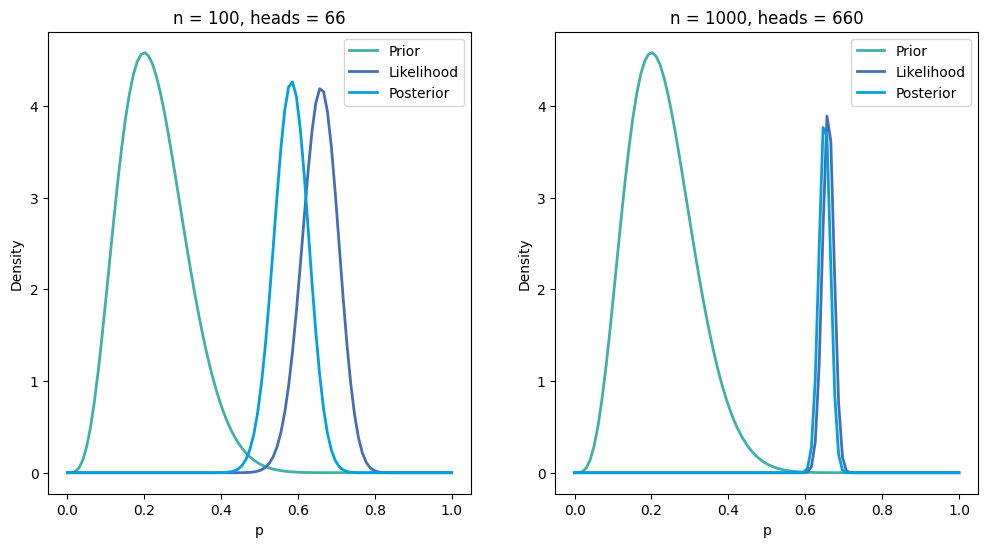

In [2]:
n = 100                             # No. of coin tosses 
heads = 66                          # No. of heads
p = np.linspace(0, 1, 100)          # True probability of heads

# Prior - beta distribution
alpha, beta = 5, 17
prior = stats.beta(alpha, beta)

# Likelihood - binomial distribution
def likelihood(p, n, heads):
    likelihood = lambda p: stats.binom.pmf(heads, n, p)
    return likelihood(p)

# Posterior 
def posterior(p, n, heads):
    posterior = lambda p: likelihood(p, n, heads) * prior.pdf(p)
    return posterior(p)

# Plotting the prior, likelihood and posterior
fig, ax = plt.subplots(1, 2, figsize = (12, 6))
ax[0].plot(p, prior.pdf(p), color = colors[0], lw = 2)
ax[0].plot(p, likelihood(p, n, heads) * 50, color = colors[1], lw = 2)
ax[0].plot(p, posterior(p, n, heads) * 18000, color = colors[2], lw = 2)
ax[0].set_xlabel('p')
ax[0].set_ylabel('Density')
ax[0].set_title(f'n = {n}, heads = {heads}')
ax[0].legend(['Prior', 'Likelihood', 'Posterior'])

ax[1].plot(p, prior.pdf(p), color = colors[0], lw = 2)
ax[1].plot(p, likelihood(p, n*10, heads*10) * 150, color = colors[1], lw = 2)
ax[1].plot(p, posterior(p, n*10, heads*10) * 200000, color = colors[2], lw = 2)
ax[1].set_xlabel('p')
ax[1].set_ylabel('Density')
ax[1].set_title(f'n = {n*10}, heads = {heads*10}')
ax[1].legend(['Prior', 'Likelihood', 'Posterior'])


## Exercise 2 - Simulating a chain

In [3]:
# Making a simulation of a chain w/ two different starting points
Xt_1 = 100
Xt_2 = -27

chain_1 = [Xt_1]
chain_2 = [Xt_2]

def gauss_pdf(x, Xt, sigma = 1):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - 0.5*Xt)**2 / (2 * sigma**2))

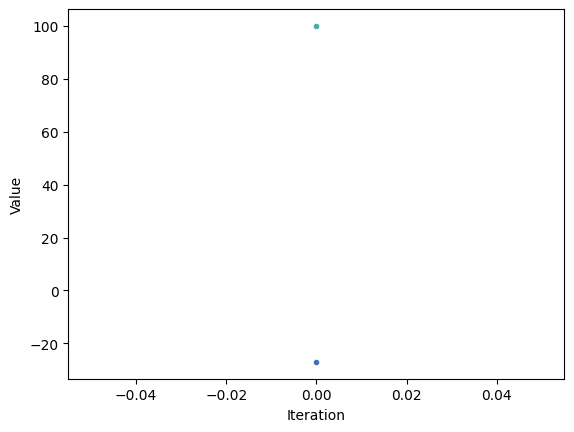

In [4]:
# Plotting the chains vs. iteration
plt.plot(chain_1, '.', color = colors[0])
plt.plot(chain_2, '.', color = colors[1])
plt.xlabel('Iteration')
plt.ylabel('Value');

## Exercise 3 - Metropolis-Hastings 

/var/folders/ws/45wzf3p157x_56fnsrq6bc4w0000gn/T/ipykernel_68205/891066748.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  r = posterior(proposal, n, heads) / posterior(current, n, heads)


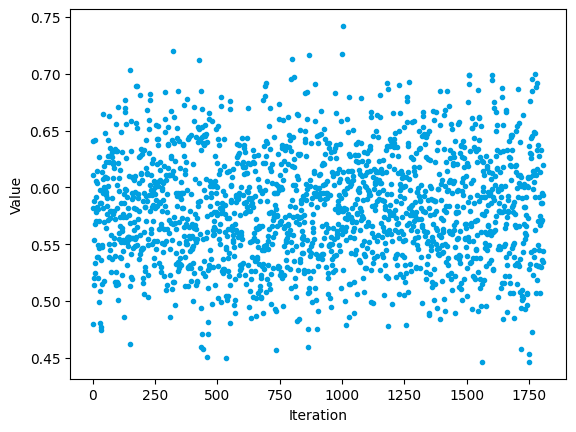

In [5]:
def prior(x, alpha= 5, beta = 17):
    return stats.beta.pdf(x, alpha, beta)

def likelihood(x, n, heads):
    return stats.binom.pmf(heads, n, x)

def posterior(x, n, heads):
    return likelihood(x, n, heads) * prior(x)

def proposal_function(current_position):
    PDF = stats.norm.rvs(0, 0.3)
    return current_position + PDF

def acceptance_probability(proposal, current):
    r = posterior(proposal, n, heads) / posterior(current, n, heads)
    return r

def metropolis_hastings(n_iterations, initial_position):
    current_position = initial_position
    accepted = []
    rejected = []

    for i in range(n_iterations):
        proposal = proposal_function(current_position)
        prob = acceptance_probability(proposal, current_position)
        if random.rand() < prob:
            current_position = proposal
            accepted.append(proposal)
        else:
            rejected.append(proposal)
    return accepted, rejected

accepted, rejected = metropolis_hastings(10000, 0)

# Plotting accepted values vs. iteration
plt.plot(accepted, '.', color = colors[2])
plt.xlabel('Iteration')
plt.ylabel('Value');

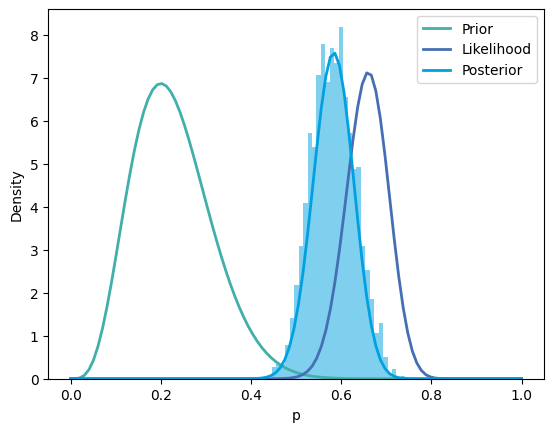

In [6]:
# Plotting the posterior, prior and likelihood from the Metropolis-Hastings chain
plt.plot(p, prior(p) * 1.5, color = colors[0], lw = 2)
plt.plot(p, likelihood(p, n, heads) * 85, color = colors[1], lw = 2)
plt.plot(p, posterior(p, n, heads) * 32000, color = colors[2], lw = 2)
plt.hist(accepted, bins = 30, density = True, color = colors[2], alpha = 0.5)
plt.xlabel('p')
plt.ylabel('Density')
plt.legend(['Prior', 'Likelihood', 'Posterior']);